# reading an exported VCell dataset from a server-side N5 store
1. set up tensorstore to point to remote dataset
2. retrieve data as a datastore object which lazily loads data upon request.

In [5]:

import matplotlib.pyplot as plt
import numpy as np
from tensorstore._tensorstore import TensorStore

from pyvcell._internal.simdata.n5_data import vcell_n5_datastore

### this configuration can be simplified by wrapping in pyvcell library

In [6]:
# https://vcell-dev.cam.uchc.edu/n5Data/ACowan/4b5ac930c40d5ba.n5?dataSetName=4248805214
url = "https://vcell-dev.cam.uchc.edu/n5Data/ACowan/4b5ac930c40d5ba.n5"
dataset_name = "4248805214"
dataset: TensorStore = vcell_n5_datastore(base_url=url, dataset_name=dataset_name)
print(f"shape = {dataset.shape}")
print(f"datastore shape = {dataset.shape}")
assert dataset.shape == (256, 256, 2, 1, 43)

datastore shape = (256, 256, 2, 1, 43)


slice shape: (256, 256)


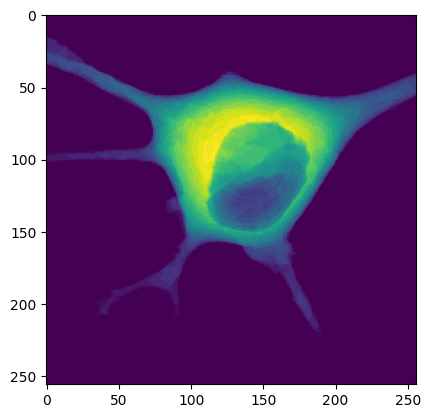

In [7]:
data: np.ndarray = dataset[:,:,0,0,0].read().result()
print("slice shape:", data.shape)

plt.imshow(data)
plt.show()
